# Rank Correlation Compared to the Initial Ranking
This notebook focuses on how consistent the produced rankings for different datasets are with the original ranking produced by a model  
**Conclusion**  
* SHAP generally produces rankings that are more consistent with the initial ranking.
* The initial ranking is crucial for the correlation.
  * If the features that the initial ranking rated high are suppressed quickly, it will have a huge impact on the correlation. Therefore:
  * It only makes sense to consider scenarios where features are suppressed slowly. If not, it is arbitrary if features ranked important are still in the dataset
* SHAP is more stable than LIME

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult", "old_adult"],
    "../data/",
)

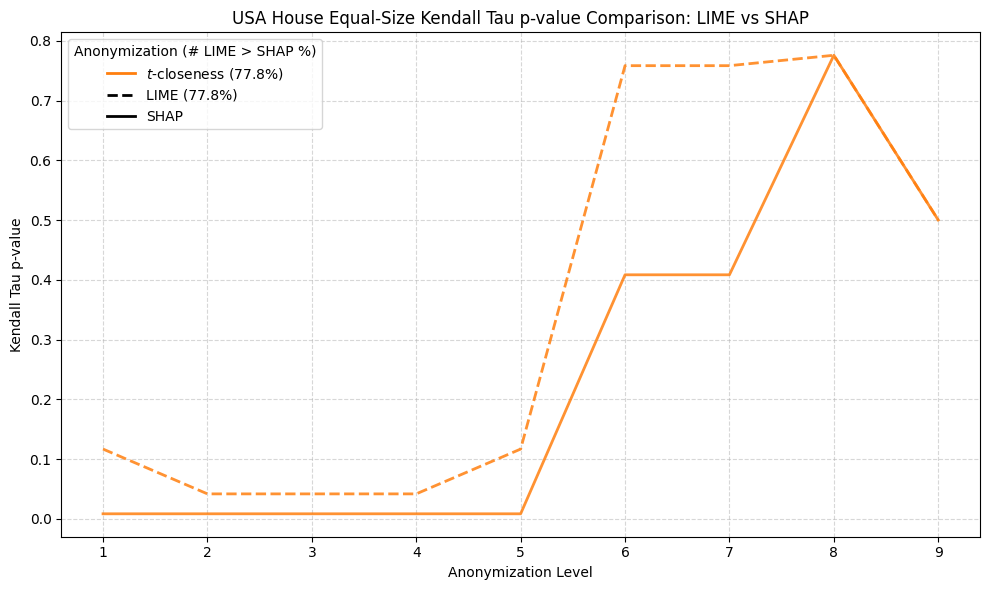

In [3]:
pl.plot_consistency("usa_house", ["t_closeness"])

So what does this plot show? It avverages all the p-values for each dataset thus producing a single p-value for dataset across different classifiers. What is interesting? That in this case, the Kendal tau's p-value between the initial ranking and the anonymized dataset for LIME is always higehr than that of SHAP. That means that here SHAP produces rankings that are more consistent, i.e. correlate, with the initial ranking produced. There is more statistical evidence for trusting a ranking produced by SHAP. It also neatly shows the instability of LIME, since it is quite wobbly compared to the one produced by SHAP. While this plot is nice and easy, let us try and consider a similar plot, but with all the annonymization methods

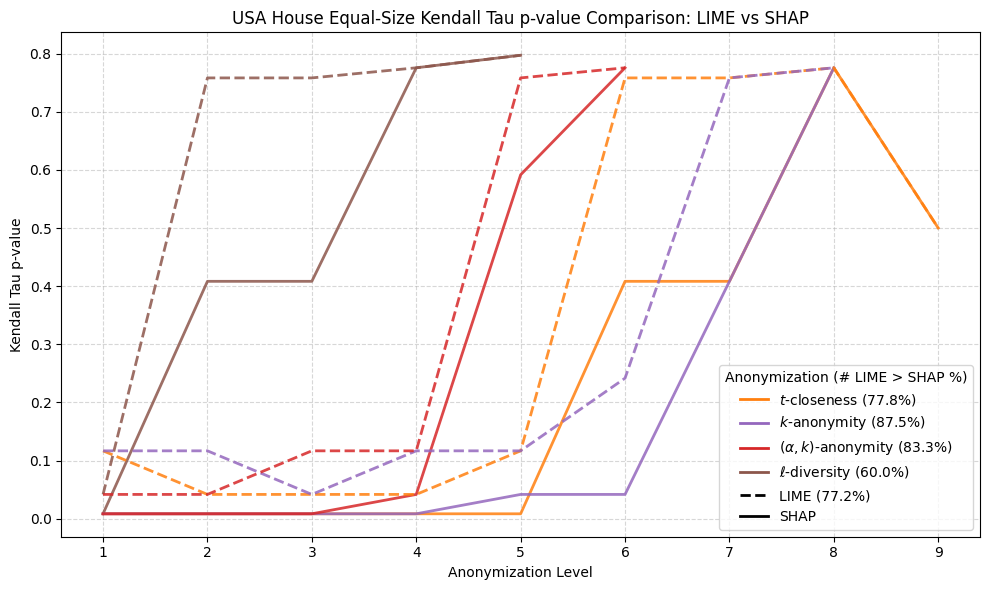

In [6]:
pl.plot_consistency("usa_house")

Now this picture is a bit more messy. But generally, we see that the p-value of SHAP is lower than that of LIME, further proving that SHAP is more consistent than LIME. Can we try and cast light on why k_anonymity and alpha_k_anonymity are so low compared to the other ones?

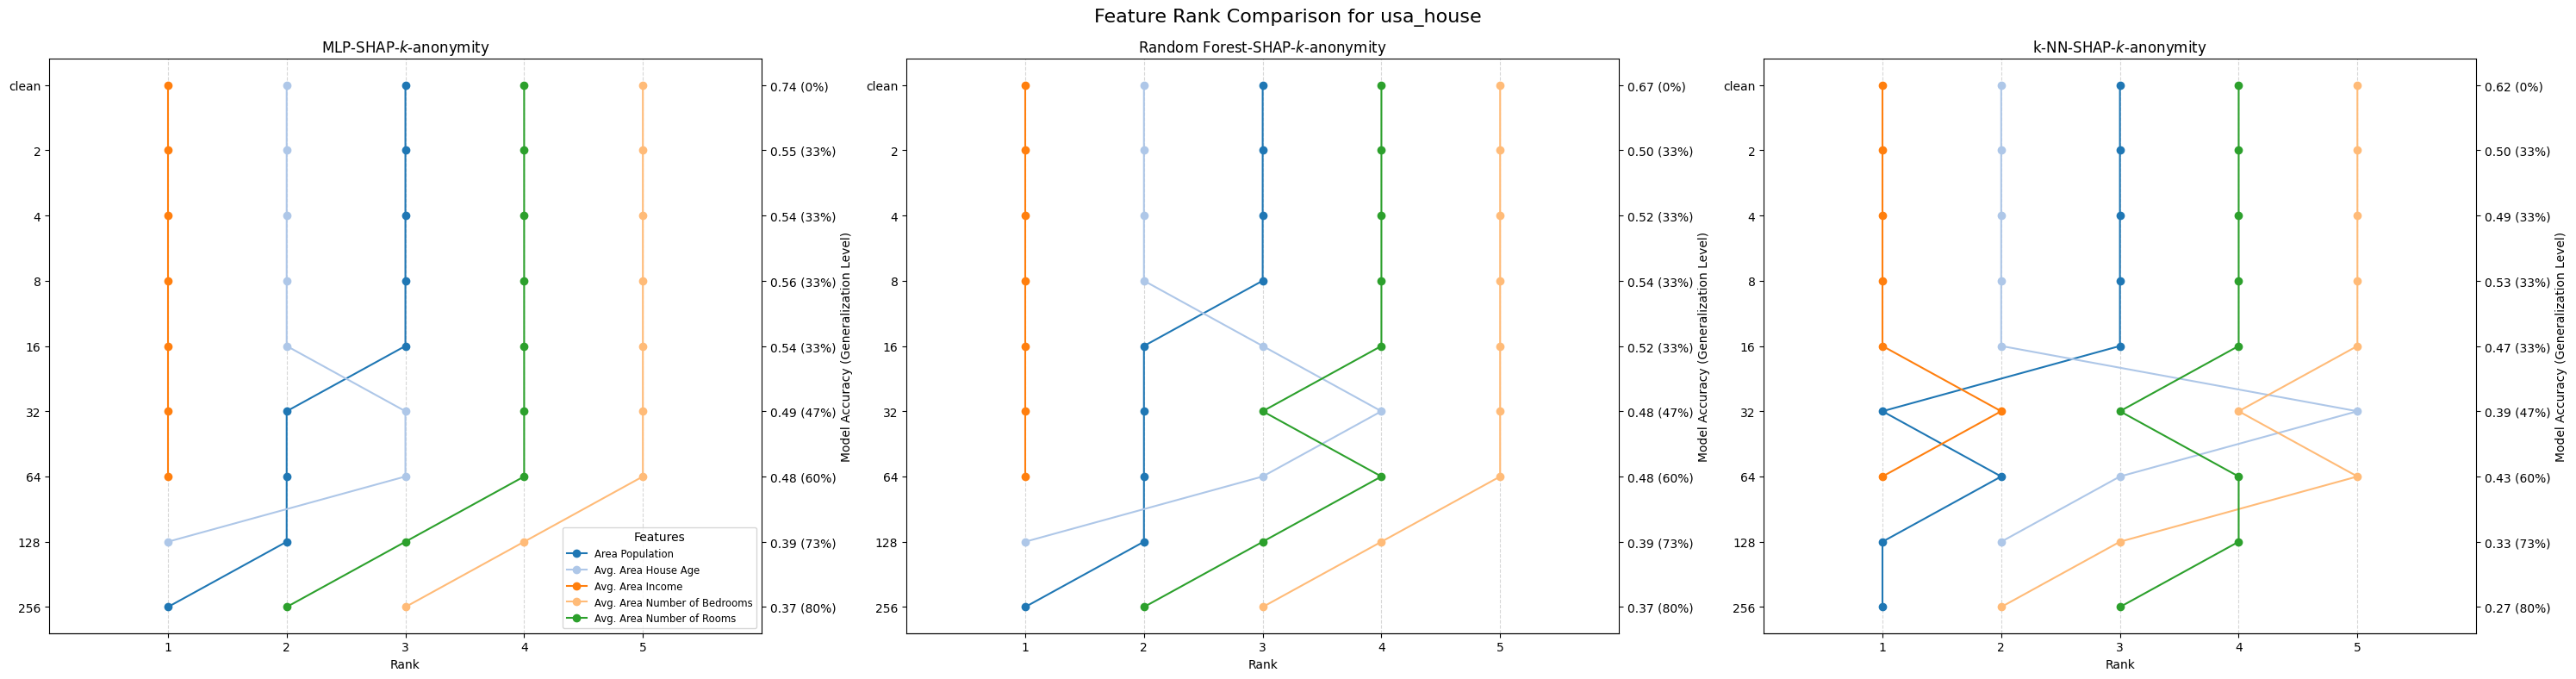

In [5]:
pl.plot_line_compare("usa_house", ["forest-shap-k_anonymity","MLP-shap-k_anonymity","knn-shap-k_anonymity"])

Not really. It is all a mess. Shows the messiness of the approach. Applying hierarchy to specifc level can result in very different rankings

Interesting enough, here we see that forest is doing much better than knn and MLP at producing stable rankings. There is definetly big jump in generalization around step 5 which does affect the rankings quite a bit. 

Let us move on to the cervic cancer dataset. We will onnly consider k_anonymity. t_closeness is generalized too much too quickly and l_diversity and alpha_k_anonymity is useless

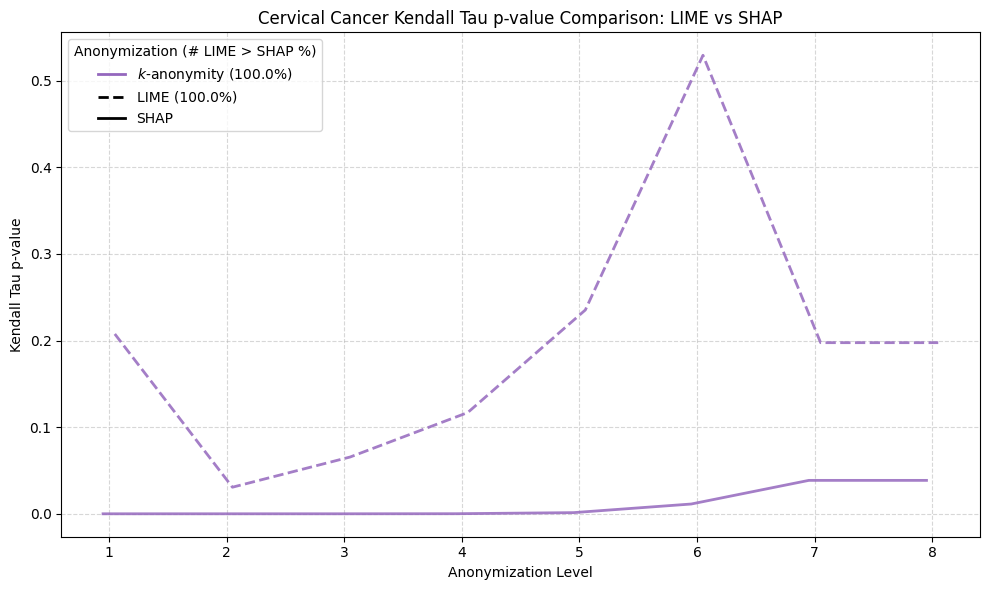

In [6]:
pl.plot_consistency("cervic_cancer", ["k_anonymity"])

We again have that SHAP outperforms LIME. We also see that the rankings become more fucked the more we generalize the dataset. But why is it so high initially?

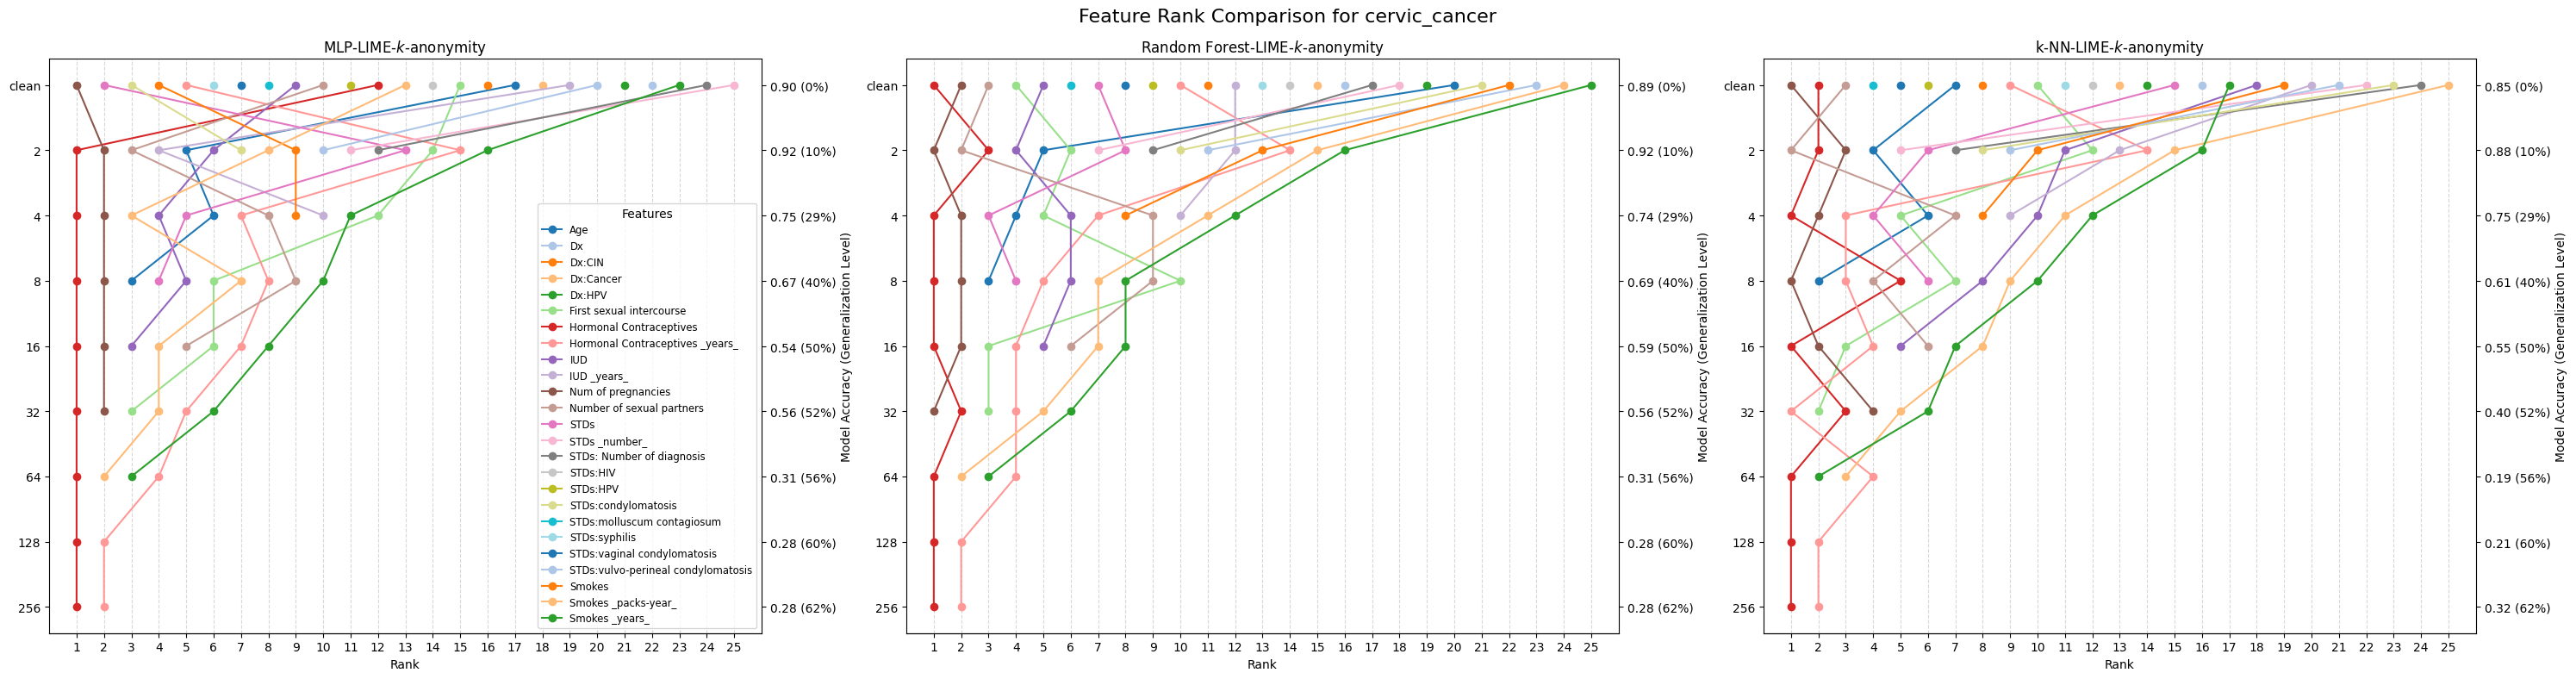

In [7]:
pl.plot_line_compare("cervic_cancer", ["forest-lime-k_anonymity","MLP-lime-k_anonymity","knn-lime-k_anonymity"])

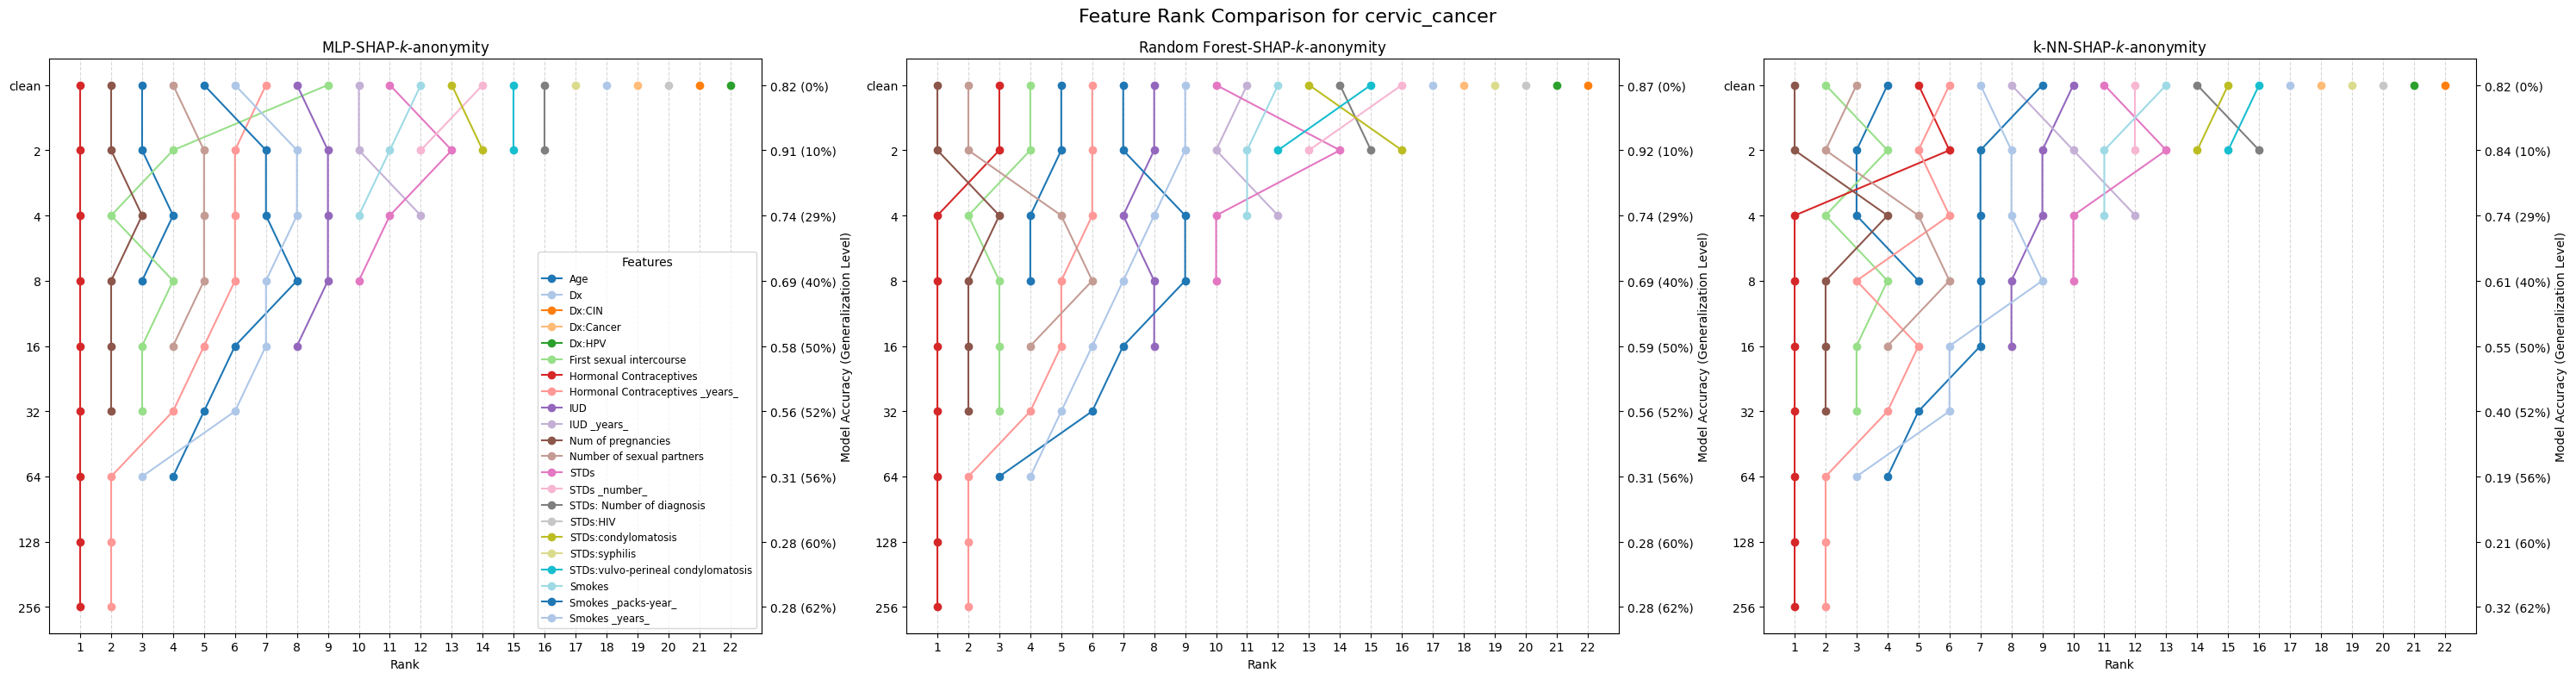

In [8]:
pl.plot_line_compare("cervic_cancer", ["forest-shap-k_anonymity","MLP-shap-k_anonymity","knn-shap-k_anonymity"])

First of all, we see that LIME considers more features important. SHAP considers 3 fewer features. Also, we see that LIME is plain unlucky. A lot of the features it rank important are suppressed right away. This is not the fault of LIME, since the the order in which features disappear in the cervic cancer dataset is very arbitrary. That also explains why the p-value decreases as generalization increases, contrary to what we might think. As more featuers are suppressed, all suppressed rankings are all assigned the same lower ranking which make it align more with the initial ranking until some critical point where it goes bad again

Let us now consider the adult dataset. Here we will disegard l_diversity and alpha_k_anonymity because it does not make sense to apply to a binary classification dataset. 

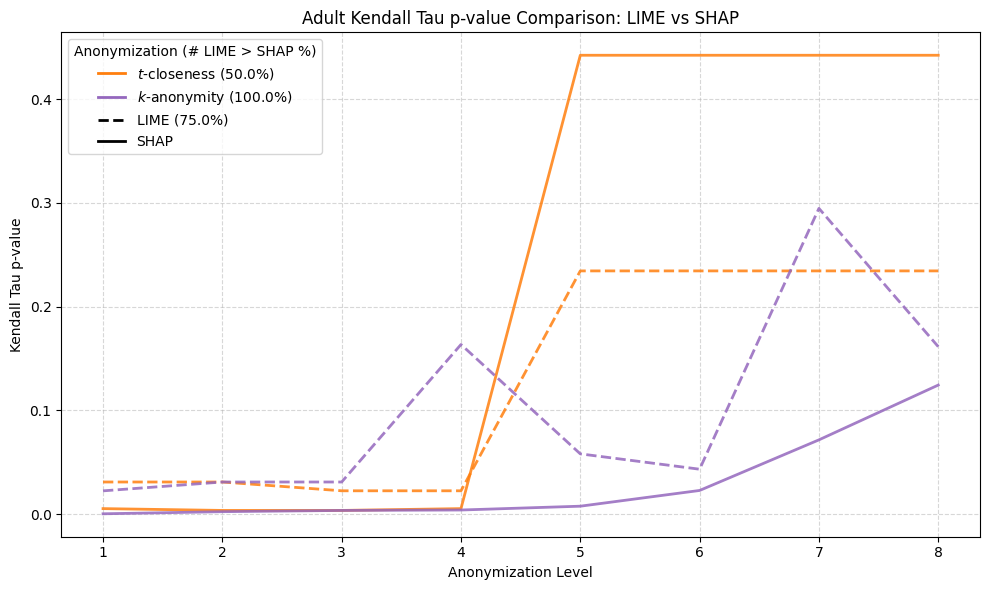

In [3]:
pl.plot_consistency("adult", ["t_closeness", "k_anonymity"])

Again, SHAP is more consistent with it's initial ranking. Again, as the dataset is more genralized, the correlation disappears. But what is up at level 5? for t_closenss. That is a big spike!

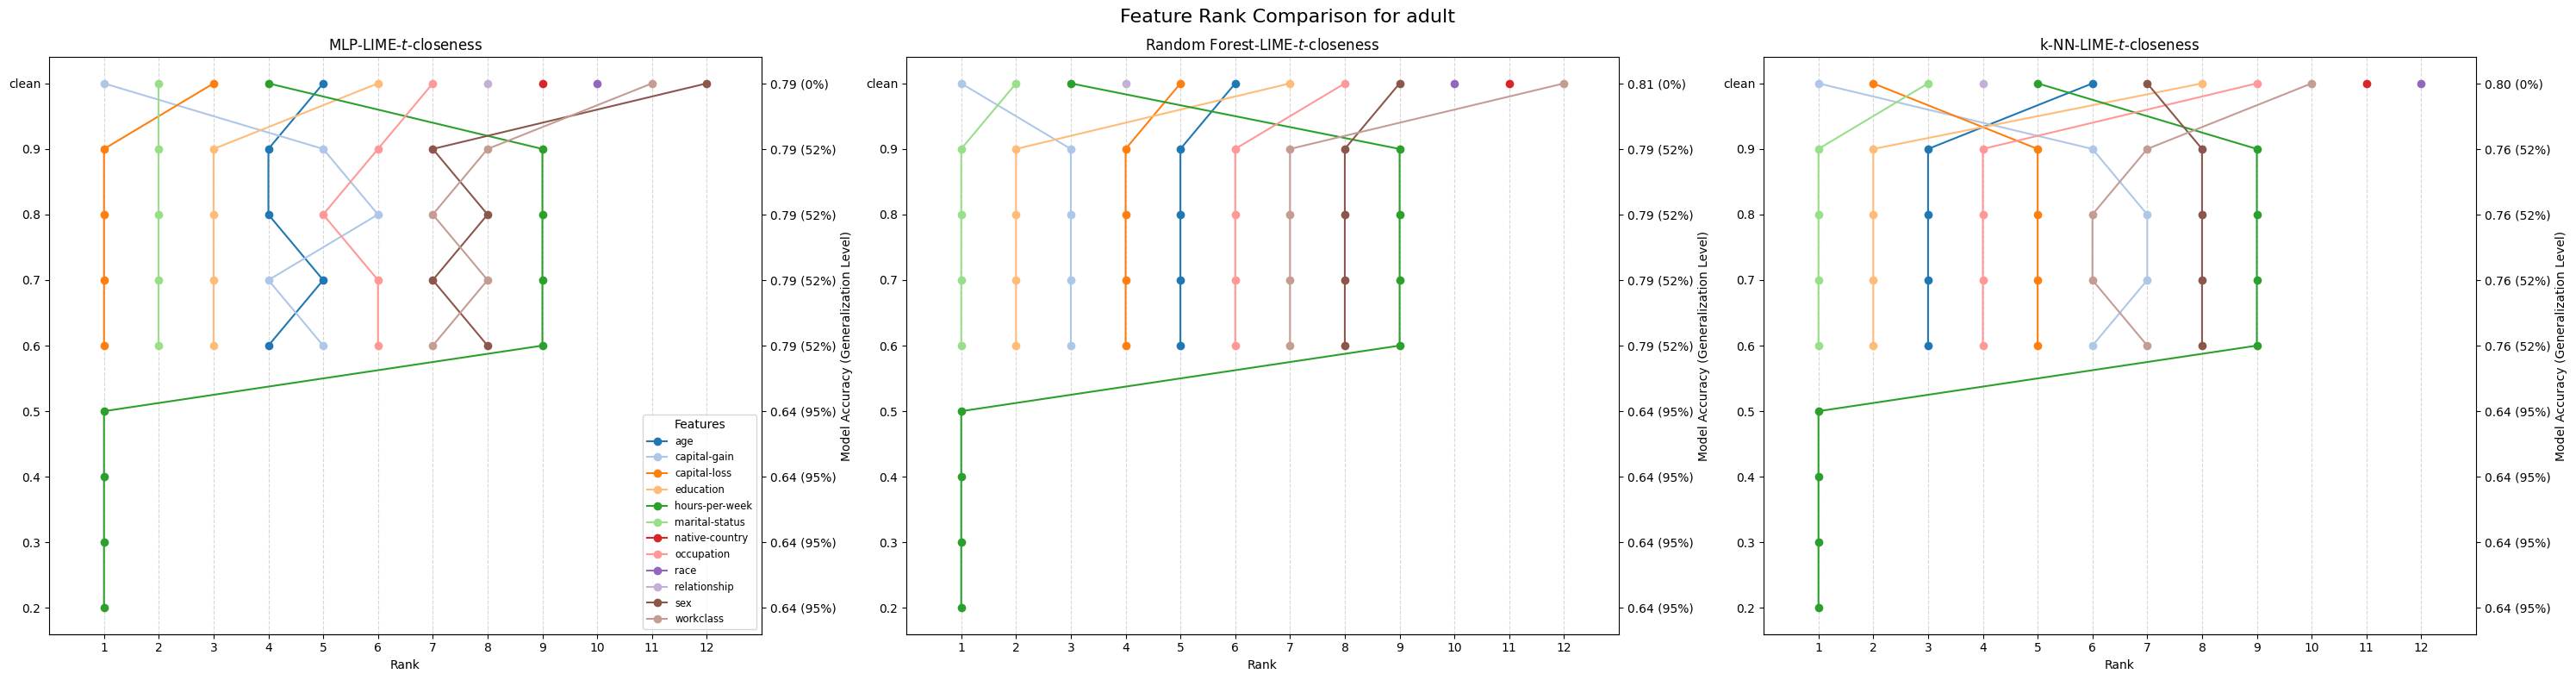

In [10]:
pl.plot_line_compare("adult", ["forest-lime-t_closeness","MLP-lime-t_closeness","knn-lime-t_closeness"])

The dataset becomes is generalized a *lot*  in one step. This explains the spike. It also perfectly illustrates another point. The features that are arbitrarily left till the very end has a HUGE impact on the ranking. If the initial ranking did not deem it important it affects the correlation a lot. In this case, LIME happened to rank hours-per-week higher than SHAP, which is why it has a much lower p-value for that level of generalization